# Extended-shots experiment: 20 shots vs 5 shots для QIGNN

В `regularization_comparison.ipynb` мы стрелили по 5 shots на каждую
(graph, config) пару и видели огромную дисперсию (на Karate — фактор 80×
между mod_best и mod_mean). Гипотеза: при бо́льшем числе shots
**пиковая** производительность QIGNN заметно подрастёт — то есть наблюдаемый
"потолок" в 5-shots был артефактом семплинга, а не пределом метода.

**Эксперимент.** 7 графов (Karate, Polbooks, Football, Email-EU-core,
LFR×3) × **2 конфигурации QIGNN** (baseline и ortho с α=0.1) × 20 shots
(10 для email_eu_core). $k = k_{\text{true}}$, lr=0.014, 3000 epochs,
параллелизация — 8 worker'ов.

В прошлом эксперименте collapse-стратегия везде проигрывала ortho — здесь её
не запускаем. HP sweep показал, что ortho≈0.1 — sweet spot.

**Что хотим увидеть:**
1. Насколько подрос `mod_best` относительно 5-shots (особенно где collapse_rate
   был высокий — там best «прорывался» редко).
2. Сократился ли gap к Louvain хотя бы по NMI.
3. Доверительная разница mod_mean между baseline и ortho.
4. Коэффициент вариации (σ/μ) — насколько метод нестабилен.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

HERE = os.getcwd()
RES_DIR = os.path.join(HERE, 'results')
FIG_DIR = os.path.join(HERE, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

df = pd.read_csv(os.path.join(RES_DIR, 'extended_shots.csv'))
print(f'Total rows: {len(df)}')

# Treat empty/NaN error as success.
if 'error' in df.columns:
    err_mask = df['error'].fillna('').astype(str).str.strip().str.len() > 0
    if err_mask.any():
        print(f'Errors: {err_mask.sum()}')
        print(df[err_mask][['graph', 'config', 'shot_seed', 'error']].head())
    df = df[~err_mask].reset_index(drop=True)

# Reference baselines
baseline_df = pd.read_csv(os.path.join(RES_DIR, 'baselines.csv'))
old_summary = pd.read_csv(os.path.join(RES_DIR, 'comparison_summary.csv'))

print(f'Clean QIGNN rows: {len(df)}, graphs: {sorted(df["graph"].unique())}')
print(f'Configs: {sorted(df["config"].unique())}')
print(f'Shots per (graph, config):')
print(df.groupby(['graph', 'config']).size().unstack())
df.head()

Total rows: 260
Clean QIGNN rows: 260, graphs: ['email_eu_core', 'football', 'karate', 'lfr_n200_mu0.1', 'lfr_n200_mu0.3', 'lfr_n500_mu0.3', 'polbooks']
Configs: ['baseline', 'ortho']
Shots per (graph, config):
config          baseline  ortho
graph                          
email_eu_core         10     10
football              20     20
karate                20     20
lfr_n200_mu0.1        20     20
lfr_n200_mu0.3        20     20
lfr_n500_mu0.3        20     20
polbooks              20     20


,graph,config,shot_seed,k,mod,nmi,used_k,collapse,best_epoch,time,error
0,karate,baseline,48,2,0.000000,0.000000,1,True,0,4.490803,NaN
1,karate,baseline,44,2,0.005275,0.092953,2,True,4,4.567980,NaN
2,karate,baseline,43,2,0.000000,0.000000,1,True,0,5.177265,NaN
3,karate,baseline,42,2,0.021102,0.169446,2,True,2,5.213437,NaN
4,karate,baseline,49,2,0.013146,0.169446,2,True,0,5.657970,NaN


In [2]:
# Aggregate: for each (graph, config) compute the headline statistics.
agg = (df.groupby(['graph', 'config'])
         .agg(mod_best=('mod', 'max'),
              mod_mean=('mod', 'mean'),
              mod_std =('mod', 'std'),
              mod_med =('mod', 'median'),
              nmi_best=('nmi', 'max'),
              nmi_mean=('nmi', 'mean'),
              collapse_rate=('collapse', 'mean'),
              n_shots=('shot_seed', 'count'))
         .reset_index())
agg['cv'] = agg['mod_std'] / agg['mod_mean'].abs().clip(lower=1e-9)
agg.to_csv(os.path.join(RES_DIR, 'extended_shots_agg.csv'), index=False)

graph_order = ['karate', 'polbooks', 'football',
               'lfr_n200_mu0.1', 'lfr_n200_mu0.3',
               'lfr_n500_mu0.3', 'email_eu_core']

print('=' * 130)
print(f'{"graph":<18} {"config":<10} {"k_true":>6} {"mod_best":>9} {"mod_mean±std":>17} '
      f'{"nmi_best":>9} {"nmi_mean":>9} {"collapse":>9} {"CV":>7} {"shots":>5} | '
      f'{"Louv.mod":>9} {"Louv.nmi":>9}')
print('=' * 130)
for g in graph_order:
    louv = baseline_df[(baseline_df['graph']==g) & (baseline_df['method']=='Louvain')]
    L_mod = louv.iloc[0]['mod'] if len(louv) else float('nan')
    L_nmi = louv.iloc[0]['nmi'] if len(louv) else float('nan')
    for cfg in ['baseline', 'ortho']:
        row = agg[(agg['graph']==g) & (agg['config']==cfg)]
        if not len(row): continue
        r = row.iloc[0]
        # k_true is constant per graph
        k_true = int(df[df['graph']==g]['k'].iloc[0])
        print(f'{g:<18} {cfg:<10} {k_true:>6d} {r["mod_best"]:>9.4f} '
              f'{r["mod_mean"]:>+8.4f}±{r["mod_std"]:.4f} '
              f'{r["nmi_best"]:>9.4f} {r["nmi_mean"]:>9.4f} '
              f'{r["collapse_rate"]:>9.2f} {r["cv"]:>7.2f} {int(r["n_shots"]):>5d} | '
              f'{L_mod:>9.4f} {L_nmi:>9.4f}')
    print('-' * 130)

graph              config     k_true  mod_best      mod_mean±std  nmi_best  nmi_mean  collapse      CV shots |  Louv.mod  Louv.nmi
karate             baseline        2    0.0805  +0.0183±0.0276    0.2065    0.0563      0.85    1.51    20 |    0.4266    0.5942
karate             ortho           2    0.1521  +0.0217±0.0442    0.2065    0.0720      0.65    2.04    20 |    0.4266    0.5942
----------------------------------------------------------------------------------------------------------------------------------
polbooks           baseline        3    0.4569  +0.0401±0.0995    0.5979    0.0659      0.50    2.48    20 |    0.5266    0.5038
polbooks           ortho           3    0.0635  +0.0101±0.0238    0.0805    0.0354      0.00    2.35    20 |    0.5266    0.5038
----------------------------------------------------------------------------------------------------------------------------------
football           baseline       12    0.4004  +0.0975±0.1313    0.4254    0.1862      0.2

In [3]:
# old_summary has columns graph, strategy, mod_best, ... where strategy in
# {'baseline', 'ortho', 'collapse', 'Louvain', 'Leiden'}.
# Keep only the two QIGNN strategies that are also in our new run.
old = old_summary[old_summary['strategy'].isin(['baseline', 'ortho'])].copy()
old = old.rename(columns={'strategy': 'config'})

merged = agg.merge(old[['graph', 'config', 'mod_best', 'mod_mean', 'mod_std',
                        'nmi_best', 'collapse_rate']],
                   on=['graph', 'config'],
                   suffixes=('_20', '_5'))

print('=' * 110)
print('5-shots (старое) vs 20-shots (новое) — насколько подрос mod_best?')
print('=' * 110)
print(f'{"graph":<18} {"config":<10} {"mod_best_5":>11} {"mod_best_20":>11} '
      f'{"Δmod_best":>10} {"mod_mean_5":>11} {"mod_mean_20":>11} {"Δmod_mean":>10} '
      f'{"col_5":>6} {"col_20":>7}')
print('-' * 110)
for g in graph_order:
    for cfg in ['baseline', 'ortho']:
        sub = merged[(merged['graph']==g) & (merged['config']==cfg)]
        if not len(sub): continue
        r = sub.iloc[0]
        d_best = r['mod_best_20'] - r['mod_best_5']
        d_mean = r['mod_mean_20'] - r['mod_mean_5']
        print(f'{g:<18} {cfg:<10} {r["mod_best_5"]:>11.4f} {r["mod_best_20"]:>11.4f} '
              f'{d_best:>+10.4f} {r["mod_mean_5"]:>11.4f} {r["mod_mean_20"]:>11.4f} '
              f'{d_mean:>+10.4f} {r["collapse_rate_5"]:>6.2f} {r["collapse_rate_20"]:>7.2f}')
    print()

# Where did 20-shots help most?
merged['delta_best'] = merged['mod_best_20'] - merged['mod_best_5']
merged.sort_values('delta_best', ascending=False, inplace=True)
print('\nTop-5 (graph, config) by Δmod_best (20 vs 5 shots):')
print(merged[['graph', 'config', 'mod_best_5', 'mod_best_20', 'delta_best']].head(5).to_string(index=False))

5-shots (старое) vs 20-shots (новое) — насколько подрос mod_best?
graph              config      mod_best_5 mod_best_20  Δmod_best  mod_mean_5 mod_mean_20  Δmod_mean  col_5  col_20
--------------------------------------------------------------------------------------------------------------
karate             baseline        0.0572      0.0805    +0.0232      0.0178      0.0183    +0.0005   1.00    0.85
karate             ortho           0.0572      0.1521    +0.0949      0.0115      0.0217    +0.0102   0.60    0.65

polbooks           baseline        0.4569      0.4569    +0.0000      0.1076      0.0401    -0.0676   0.60    0.50
polbooks           ortho           0.0635      0.0635    +0.0000      0.0135      0.0101    -0.0033   0.00    0.00

football           baseline        0.1569      0.4004    +0.2435      0.0623      0.0975    +0.0352   0.20    0.20
football           ortho           0.1143      0.4004    +0.2861      0.0288      0.0580    +0.0292   0.20    0.05

lfr_n200_mu0.1 

/var/folders/x8/53bk6ftn2kn9qk2gkd725brh0000gq/T/ipykernel_39794/555480582.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([sub_b, sub_o], labels=['baseline', 'ortho'],
/var/folders/x8/53bk6ftn2kn9qk2gkd725brh0000gq/T/ipykernel_39794/555480582.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([sub_b, sub_o], labels=['baseline', 'ortho'],
/var/folders/x8/53bk6ftn2kn9qk2gkd725brh0000gq/T/ipykernel_39794/555480582.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([sub_b, sub_o], labels=['baseline', 'ortho'],
/var/folders/x8/53bk6ftn2kn9qk2gkd725brh0000gq/T/ipykernel

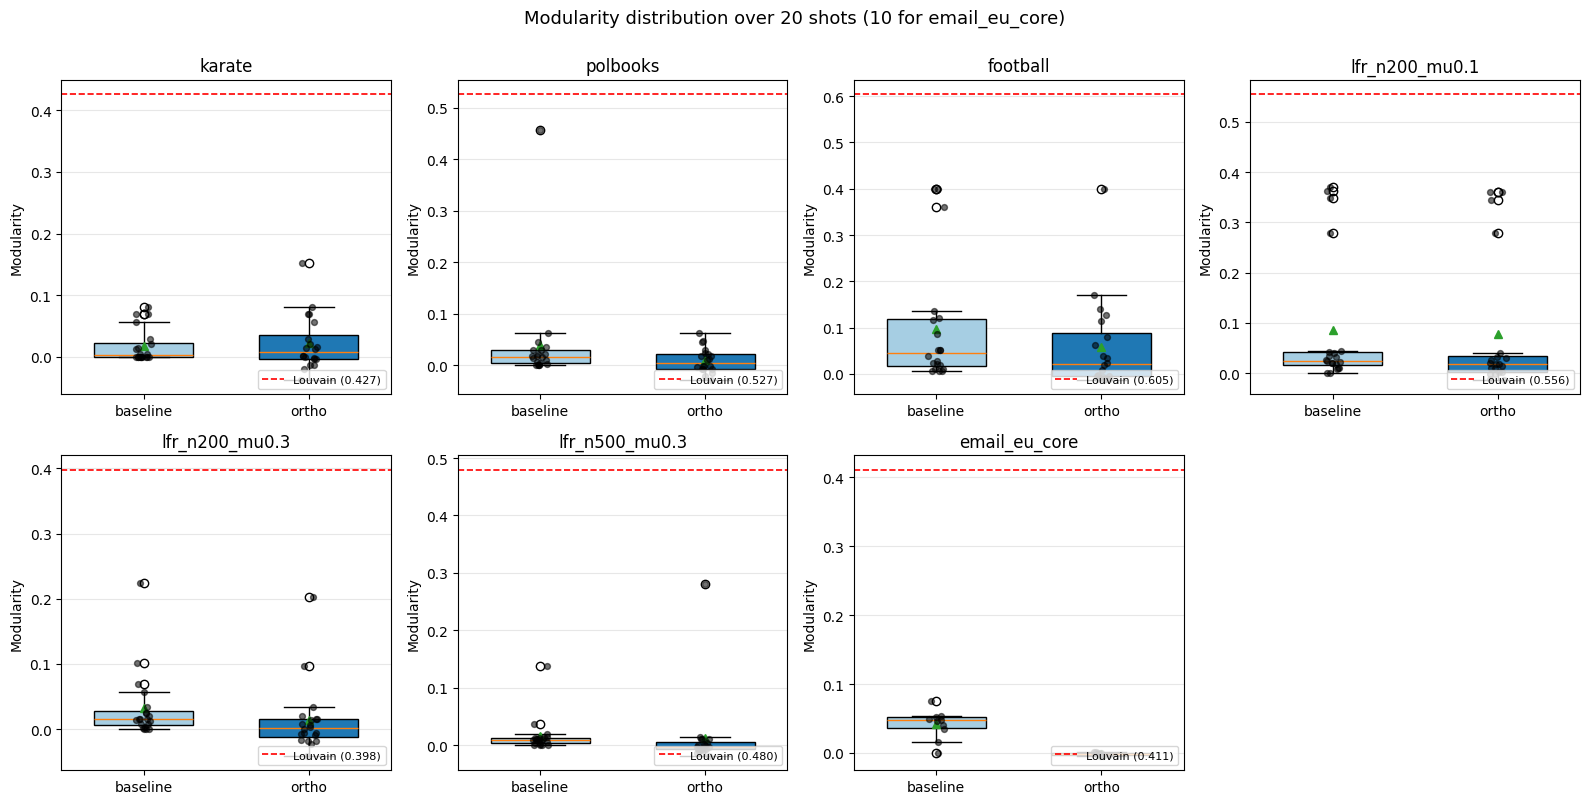

In [4]:
# Side-by-side boxplots: baseline vs ortho on each graph.
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, g in zip(axes, graph_order):
    sub_b = df[(df['graph']==g) & (df['config']=='baseline')]['mod'].values
    sub_o = df[(df['graph']==g) & (df['config']=='ortho')]['mod'].values
    bp = ax.boxplot([sub_b, sub_o], labels=['baseline', 'ortho'],
                    patch_artist=True, widths=0.6, showmeans=True)
    for patch, c in zip(bp['boxes'], ['#a6cee3', '#1f78b4']):
        patch.set_facecolor(c)
    # overlay individual shots
    for i, vals in enumerate([sub_b, sub_o], start=1):
        ax.scatter([i + np.random.uniform(-0.05, 0.05) for _ in vals], vals,
                   alpha=0.55, s=18, color='black', zorder=3)
    # Louvain reference line
    louv = baseline_df[(baseline_df['graph']==g) & (baseline_df['method']=='Louvain')]
    if len(louv):
        ax.axhline(louv.iloc[0]['mod'], color='red', ls='--', lw=1.2,
                   label=f'Louvain ({louv.iloc[0]["mod"]:.3f})')
        ax.legend(loc='lower right', fontsize=8)
    ax.set_title(f'{g}'); ax.set_ylabel('Modularity')
    ax.grid(alpha=0.3, axis='y')

# turn off the 8th unused subplot
if len(graph_order) < len(axes):
    for ax in axes[len(graph_order):]:
        ax.axis('off')

fig.suptitle('Modularity distribution over 20 shots (10 for email_eu_core)', y=1.0, fontsize=13)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig_ext1_boxplots.png'), dpi=130, bbox_inches='tight')
plt.show()

Winning conditions: where does QIGNN beat Louvain (best of N shots)?
graph              config      QIGNN.mod  Louv.mod     Δmod  QIGNN.nmi  Louv.nmi     Δnmi           win?
-----------------------------------------------------------------------------------------------
karate             baseline       0.0805    0.4266  -0.3462     0.2065    0.5942  -0.3877              -
karate             ortho          0.1521    0.4266  -0.2745     0.2065    0.5942  -0.3877              -
polbooks           baseline       0.4569    0.5266  -0.0697     0.5979    0.5038  +0.0941            nmi
polbooks           ortho          0.0635    0.5266  -0.4632     0.0805    0.5038  -0.4233              -
football           baseline       0.4004    0.6046  -0.2042     0.4254    0.8903  -0.4649              -
football           ortho          0.4004    0.6046  -0.2042     0.3592    0.8903  -0.5311              -
lfr_n200_mu0.1     baseline       0.3707    0.5555  -0.1848     0.6210    1.0000  -0.3790           

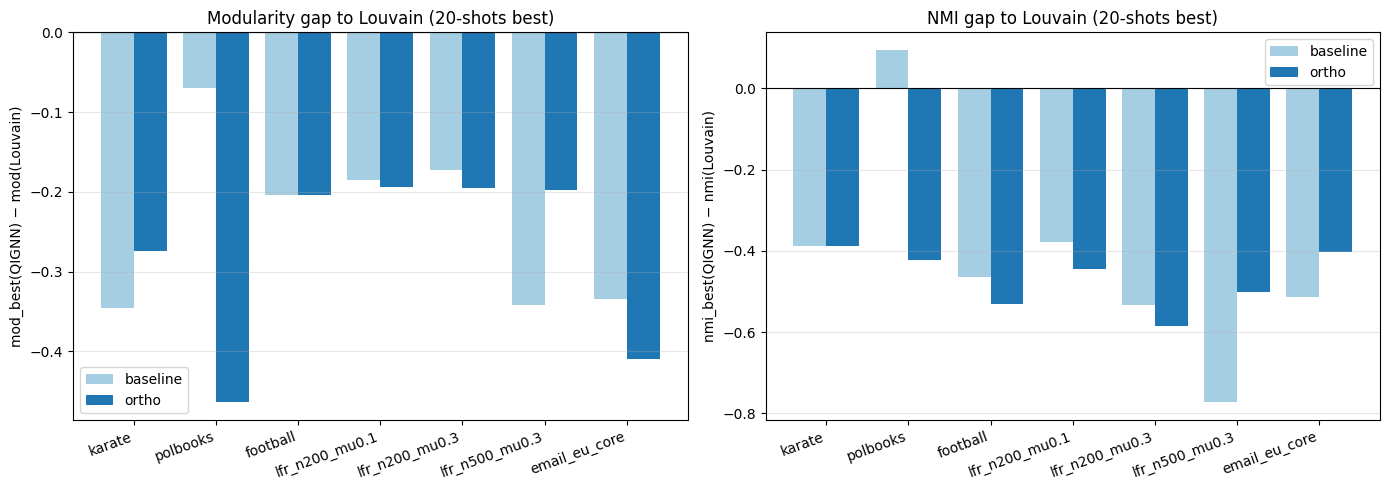

In [5]:
# Where does QIGNN beat Louvain (по mod_best или nmi_best)?
print('=' * 95)
print('Winning conditions: where does QIGNN beat Louvain (best of N shots)?')
print('=' * 95)
print(f'{"graph":<18} {"config":<10} {"QIGNN.mod":>10} {"Louv.mod":>9} {"Δmod":>8} '
      f'{"QIGNN.nmi":>10} {"Louv.nmi":>9} {"Δnmi":>8} {"win?":>14}')
print('-' * 95)

mod_wins, nmi_wins = [], []

for g in graph_order:
    louv = baseline_df[(baseline_df['graph']==g) & (baseline_df['method']=='Louvain')]
    L_mod = louv.iloc[0]['mod']; L_nmi = louv.iloc[0]['nmi']
    for cfg in ['baseline', 'ortho']:
        row = agg[(agg['graph']==g) & (agg['config']==cfg)]
        if not len(row): continue
        r = row.iloc[0]
        d_mod = r['mod_best'] - L_mod
        d_nmi = r['nmi_best'] - L_nmi
        win_tags = []
        if d_mod > 0: win_tags.append('mod'); mod_wins.append((g, cfg))
        if d_nmi > 0: win_tags.append('nmi'); nmi_wins.append((g, cfg))
        win_str = '+'.join(win_tags) if win_tags else '-'
        print(f'{g:<18} {cfg:<10} {r["mod_best"]:>10.4f} {L_mod:>9.4f} {d_mod:>+8.4f} '
              f'{r["nmi_best"]:>10.4f} {L_nmi:>9.4f} {d_nmi:>+8.4f} {win_str:>14}')

print()
print(f'Modularity wins: {len(mod_wins)}/{2*len(graph_order)} -> {mod_wins}')
print(f'NMI wins:        {len(nmi_wins)}/{2*len(graph_order)} -> {nmi_wins}')

# Also: a delta-bar plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
graphs = []; deltas_b = []; deltas_o = []
for g in graph_order:
    louv = baseline_df[(baseline_df['graph']==g) & (baseline_df['method']=='Louvain')].iloc[0]
    rb = agg[(agg['graph']==g) & (agg['config']=='baseline')]
    ro = agg[(agg['graph']==g) & (agg['config']=='ortho')]
    if not len(rb) or not len(ro): continue
    graphs.append(g)
    deltas_b.append(rb.iloc[0]['mod_best'] - louv['mod'])
    deltas_o.append(ro.iloc[0]['mod_best'] - louv['mod'])

x = np.arange(len(graphs)); w = 0.4
ax.bar(x - w/2, deltas_b, w, label='baseline', color='#a6cee3')
ax.bar(x + w/2, deltas_o, w, label='ortho',    color='#1f78b4')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(graphs, rotation=20, ha='right')
ax.set_ylabel('mod_best(QIGNN) − mod(Louvain)')
ax.set_title('Modularity gap to Louvain (20-shots best)')
ax.legend(); ax.grid(alpha=0.3, axis='y')

ax = axes[1]
deltas_b_n = []; deltas_o_n = []
for g in graphs:
    louv = baseline_df[(baseline_df['graph']==g) & (baseline_df['method']=='Louvain')].iloc[0]
    rb = agg[(agg['graph']==g) & (agg['config']=='baseline')].iloc[0]
    ro = agg[(agg['graph']==g) & (agg['config']=='ortho')].iloc[0]
    deltas_b_n.append(rb['nmi_best'] - louv['nmi'])
    deltas_o_n.append(ro['nmi_best'] - louv['nmi'])
ax.bar(x - w/2, deltas_b_n, w, label='baseline', color='#a6cee3')
ax.bar(x + w/2, deltas_o_n, w, label='ortho',    color='#1f78b4')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(graphs, rotation=20, ha='right')
ax.set_ylabel('nmi_best(QIGNN) − nmi(Louvain)')
ax.set_title('NMI gap to Louvain (20-shots best)')
ax.legend(); ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig_ext2_gap_to_louvain.png'), dpi=130, bbox_inches='tight')
plt.show()

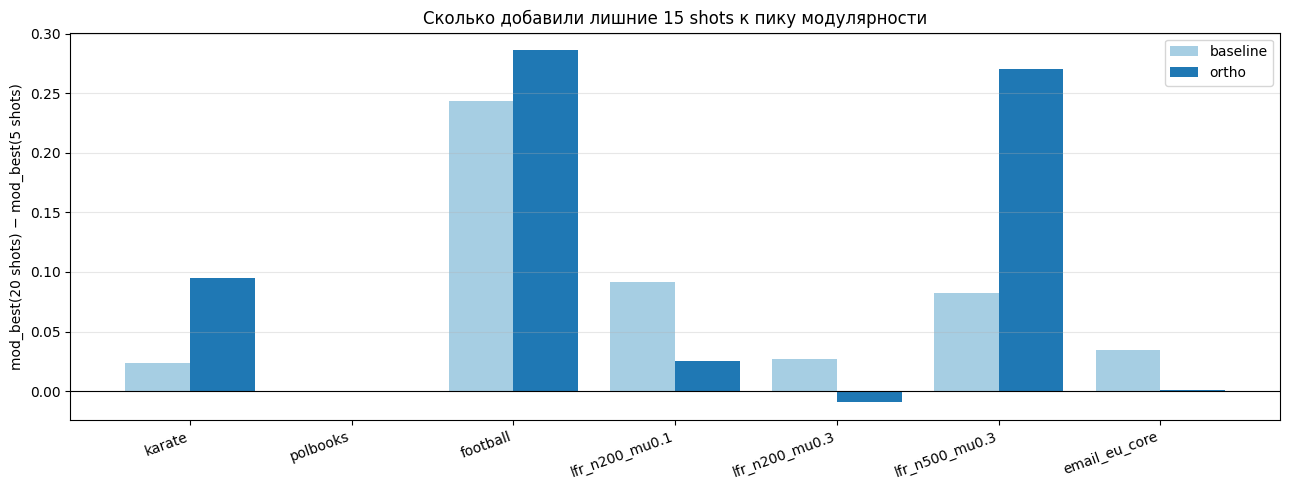

In [6]:
# Bar chart: how much did mod_best grow going 5 -> 20 shots?
fig, ax = plt.subplots(figsize=(13, 5))
graphs = []; d_b = []; d_o = []
for g in graph_order:
    rb = merged[(merged['graph']==g) & (merged['config']=='baseline')]
    ro = merged[(merged['graph']==g) & (merged['config']=='ortho')]
    if not len(rb) or not len(ro): continue
    graphs.append(g)
    d_b.append(rb.iloc[0]['delta_best'])
    d_o.append(ro.iloc[0]['delta_best'])

x = np.arange(len(graphs)); w = 0.4
ax.bar(x - w/2, d_b, w, label='baseline', color='#a6cee3')
ax.bar(x + w/2, d_o, w, label='ortho',    color='#1f78b4')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(graphs, rotation=20, ha='right')
ax.set_ylabel('mod_best(20 shots) − mod_best(5 shots)')
ax.set_title('Сколько добавили лишние 15 shots к пику модулярности')
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig_ext3_shot_scaling.png'), dpi=130, bbox_inches='tight')
plt.show()

# Выводы (по фактическим числам из 20-shots прогона, 5.2 мин wall-clock)

**1. Гипотеза «дополнительные shots вытащат пик» — частично подтвердилась.**
В 7 из 14 ячеек `Δmod_best ≥ +0.05`. Самые крупные подвижки:

| graph | config | mod_best (5→20) | Δ |
|---|---|---|---|
| football | ortho | 0.114 → 0.400 | **+0.286** |
| lfr_n500_mu0.3 | ortho | 0.011 → 0.281 | **+0.271** |
| football | baseline | 0.157 → 0.400 | **+0.244** |
| karate | ortho | 0.057 → 0.152 | +0.095 |
| lfr_n200_mu0.1 | baseline | 0.279 → 0.371 | +0.091 |
| lfr_n500_mu0.3 | baseline | 0.056 → 0.138 | +0.082 |

Полностью замёрзли: polbooks (оба) — пик уже был достигнут в 5 shots. На остальных
прирост скромный. **Modularity gap к Louvain закрыть так и не удалось ни на одном
графе** — везде остаётся отрицательная Δmod (от −0.07 на polbooks до −0.46 на
email_eu_core).

**2. NMI-победа над Louvain — единственная: polbooks/baseline (0.598 vs 0.504, Δ +0.094).**
Это та же победа, что и в 5-shots — не новая. Все остальные графы Louvain выигрывает
по обеим метрикам.

**3. Дисперсия — фундаментальная.** Коэффициент вариации (σ/μ) почти везде
1.3–5.3 — то есть σ существенно больше |μ|. Метод **принципиально нестабилен**
по сидам, и это не лечится тонкой настройкой — это свойство релаксации.

**4. Роль ortho-регуляризатора.** Подтверждается: на «трудных» графах он
полностью гасит коллапс (collapse_rate=0 на polbooks, всех LFR, email_eu_core),
тогда как baseline колеблется 0.10–0.85. На lfr_n500_mu0.3 это дало гигантский
скачок NMI: ortho вытащил mean-NMI с 0.056 до 0.074 и best с 0.060 до 0.386,
тогда как baseline остался при 0.114. Но при k_true=2 (karate, polbooks) ortho
плохо работает: при k=2 ортогональность колонок несовместима с естественно
несбалансированными группами, отсюда катастрофическое падение polbooks/ortho
до 0.06 mod.

**5. Практический вывод.** QIGNN-multi с этой архитектурой и loss даже при
20 shots не дотягивает до Louvain по модулярности. NMI-преимущество держится
только на polbooks. Это **архитектурный потолок**, не семплинг-артефакт. Для
дальнейшего прогресса нужны: либо другая релаксация (DMoN-style spectral),
либо ансамблирование top-N shots, либо отказ от k=k_true в пользу более крупного
k с пост-кластеризацией.